  symbol                                               name currency  \
0  AABXX             SEI Daily Income Trust Government Fund      USD   
1  AAFXX                     American Funds U.S. Government      USD   
2  AALXX                         Thrivent Money Market Fund      USD   
3  AAOXX  American Beacon U.S. Government Money Market S...      USD   
4  AARXX                             AARP Money Market Fund      USD   

                                             summary                 family  \
0  SEI Daily Income Trust Government Fund is a mo...                    NaN   
1  American Funds U.S. Government is a money mark...                    NaN   
2  Thrivent Money Market Fund is a money market f...  Thrivent Mutual Funds   
3  American Beacon U.S. Government Money Market S...                    NaN   
4  AARP Money Market Fund is a money market fund ...                    NaN   

  exchange  
0      NAS  
1      NAS  
2      NAS  
3      NAS  
4      NAS  
Index(['symbol

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4547/1812870793.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


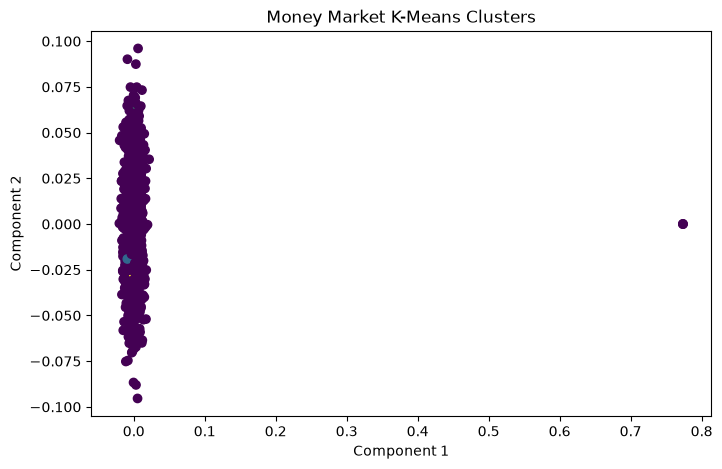


Clustering completed!
Cluster
0    1206
2       1
3       1
1       1
Name: count, dtype: int64


In [1]:
# NLP + K-MEANS ON moneymarkets.csv

import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# 1. Load dataset
df = pd.read_csv("moneymarkets.csv")
print(df.head())
print(df.columns)

# 2. Select text column automatically
text_col = df.select_dtypes(include="object").columns[0]
df[text_col] = df[text_col].fillna("").astype(str)

# 3. Clean text
def clean_text(x):
    x = x.lower()
    x = re.sub(r"http\S+|[^a-z\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

df["clean_text"] = df[text_col].apply(clean_text)

# 4. NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 6. Show cluster keywords
words = tfidf.get_feature_names_out()

for i in range(k):
    top_words = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:",
          ", ".join(words[j] for j in top_words))

# 7. 2D visualisation
X_2D = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=df["Cluster"])
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Money Market K-Means Clusters")
plt.show()

# 8. Save results
df.to_csv("moneymarkets_clustered.csv", index=False)

print("\nClustering completed!")
print(df["Cluster"].value_counts())